## 1 · Data loading & alignment

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

### 1.1 Load forecast log

In [5]:
flog = pd.read_csv('val_check_1/forecast_log.csv')
flog['mop_time'] = pd.to_datetime(flog['mop_time'], utc=True)
flog['bin'] = flog['bin'].str.strip()
flog = flog.sort_values('mop_time').reset_index(drop=True)

print(f"Rows: {len(flog)}")
print(f"Date range: {flog['mop_time'].min()} → {flog['mop_time'].max()}")
print(f"Bins:\n{flog['bin'].value_counts()}")
print(f"Confidence:\n{flog['confidence'].value_counts()}")

Rows: 142
Date range: 2026-04-06 19:00:00+00:00 → 2026-04-14 23:00:00+00:00
Bins:
bin
NW  (290–330°)     54
S   (150–200°)     33
WNW (260–290°)     27
SW  (200–230°)     17
W   (230–260°)     10
global fallback     1
Name: count, dtype: int64
Confidence:
confidence
MEDIUM    64
HIGH      50
LOW       28
Name: count, dtype: int64


### 1.2 Load buoy embedded history

In [6]:
buoy_raw = pd.read_csv('val_check_1/SPOT-1644_2026-04-06_2026-04-16_embedded-history.csv')

buoy = buoy_raw[buoy_raw['Significant Wave Height (m)'] != '-'].copy()
buoy['ts'] = pd.to_datetime(buoy['Epoch Time'].astype(int), unit='s', utc=True)
buoy['Hs'] = buoy['Significant Wave Height (m)'].astype(float)
buoy['Tp'] = buoy['Peak Period (s)'].astype(float)
buoy['Dp'] = buoy['Peak Direction (deg)'].astype(float)
buoy = buoy[['ts','Hs','Tp','Dp']].sort_values('ts').reset_index(drop=True)

print(f"Rows with Hs: {len(buoy)}")
print(f"Date range: {buoy['ts'].min()} → {buoy['ts'].max()}")
print(f"Hs range: {buoy['Hs'].min():.2f} – {buoy['Hs'].max():.2f} m")
print(f"Dp range: {buoy['Dp'].min():.0f} – {buoy['Dp'].max():.0f} °")

Rows with Hs: 426
Date range: 2026-04-06 04:15:31+00:00 → 2026-04-15 01:04:55+00:00
Hs range: 0.36 – 1.28 m
Dp range: 169 – 268 °


### 1.3 Nearest-neighbour timestamp join

For each hourly forecast row, find the closest buoy observation in time. Only keep pairs within 60 minutes. From the cadence analysis we know the buoy runs every 30 minutes, so the worst-case delta should be ~15 minutes.

In [7]:
MATCH_WINDOW = 60  # minutes

buoy_indexed = buoy.set_index('ts').sort_index()

matched_rows = []
for _, fr in flog.iterrows():
    ft = fr['mop_time']
    idx = buoy_indexed.index.get_indexer([ft], method='nearest')[0]
    nearest = buoy_indexed.iloc[idx]
    dt_min = abs((nearest.name - ft).total_seconds()) / 60
    if dt_min <= MATCH_WINDOW:
        matched_rows.append({
            'time':       ft,
            'mop_raw':    fr['Hs_mop_raw'],
            'corrected':  fr['Hs_corrected'],
            'harvest':    fr['harvest_Hs'],
            'scale':      fr['scale_factor'],
            'bin':        fr['bin'],
            'confidence': fr['confidence'],
            'buoy_Hs':    nearest['Hs'],
            'buoy_Tp':    nearest['Tp'],
            'buoy_Dp':    nearest['Dp'],
            'dt_min':     dt_min,
        })

df = pd.DataFrame(matched_rows).sort_values('time').reset_index(drop=True)

print(f"Matched: {len(df)} / {len(flog)} forecast rows")
print(f"Avg Δt: {df['dt_min'].mean():.1f} min  |  Max Δt: {df['dt_min'].max():.1f} min")

Matched: 142 / 142 forecast rows
Avg Δt: 7.6 min  |  Max Δt: 14.5 min


### 1.4 Derived columns

Add bias and ratio columns we'll use throughout the analysis.

In [8]:
df['bias_raw']  = df['mop_raw']   - df['buoy_Hs']
df['bias_corr'] = df['corrected'] - df['buoy_Hs']
df['ratio_raw'] = df['buoy_Hs']   / df['mop_raw']

df.head(8)

,time,mop_raw,corrected,harvest,scale,bin,confidence,buoy_Hs,buoy_Tp,buoy_Dp,dt_min,bias_raw,bias_corr,ratio_raw
0,2026-04-06 19:00:00+00:00,0.734,0.918,1.68,1.2515,NW (290–330°),MEDIUM,0.81,5.68,258.406,14.483333,-0.076,0.108,1.103542
1,2026-04-06 20:00:00+00:00,0.729,0.821,1.80,1.1260,S (150–200°),HIGH,0.79,5.68,263.823,14.483333,-0.061,0.031,1.083676
2,2026-04-06 21:00:00+00:00,0.857,1.072,1.88,1.2515,NW (290–330°),MEDIUM,0.71,5.68,261.490,14.483333,0.147,0.362,0.828471
3,2026-04-06 22:00:00+00:00,1.019,1.147,1.97,1.1260,S (150–200°),HIGH,0.92,6.02,257.242,14.483333,0.099,0.227,0.902846
4,2026-04-06 23:00:00+00:00,1.007,1.260,2.11,1.2515,NW (290–330°),MEDIUM,1.16,5.68,253.927,14.483333,-0.153,0.100,1.151936
5,2026-04-07 03:00:00+00:00,0.915,1.030,2.09,1.1260,S (150–200°),HIGH,0.94,5.12,249.741,14.483333,-0.025,0.090,1.027322
6,2026-04-07 04:00:00+00:00,0.928,1.162,1.97,1.2515,NW (290–330°),MEDIUM,0.89,5.68,247.850,14.483333,0.038,0.272,0.959052
7,2026-04-07 06:00:00+00:00,0.958,1.198,1.91,1.2515,NW (290–330°),MEDIUM,0.91,5.12,250.274,14.483333,0.048,0.288,0.949896


## 2 · Raw overview — 9-day time series

Direction bins are assigned from Harvest offshore direction, not buoy direction. The buoy_Dp column reflects what actually arrived at Campus Point, which will diverge from the bin label due to Channel Islands refraction and shadowing.

In [14]:
CONF_COLOR = {'HIGH': '#2ecc71', 'MEDIUM': '#f39c12', 'LOW': '#e74c3c'}
BIN_COLOR = {
    'NW  (290–330°)':  '#2980b9',
    'WNW (260–290°)':  '#8e44ad',
    'W   (230–260°)':  '#16a085',
    'SW  (200–230°)':  '#d35400',
    'S   (150–200°)':  '#c0392b',
    'global fallback': '#7f8c8d',
}

### 2.1 Hs time series — all three signals

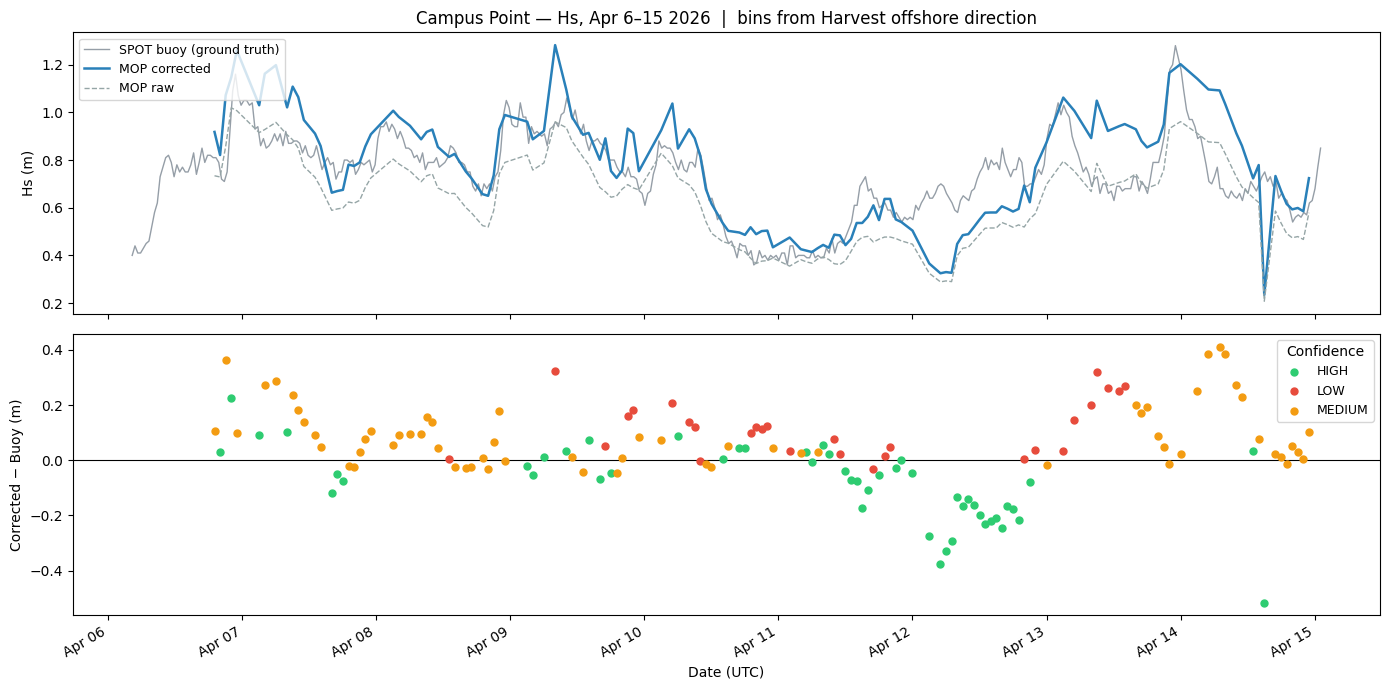

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# top panel: three Hs signals
ax = axes[0]
ax.plot(buoy['ts'], buoy['Hs'],
        color='#2c3e50', lw=1, alpha=0.5, label='SPOT buoy (ground truth)')
ax.plot(df['time'], df['corrected'],
        color='#2980b9', lw=1.8, label='MOP corrected')
ax.plot(df['time'], df['mop_raw'],
        color='#95a5a6', lw=1, ls='--', label='MOP raw')
ax.set_ylabel('Hs (m)')
ax.set_title('Campus Point — Hs, Apr 6–15 2026  |  bins from Harvest offshore direction')
ax.legend(loc='upper left', fontsize=9)

# bottom panel: bias over time, coloured by confidence
ax2 = axes[1]
for conf, grp in df.groupby('confidence'):
    ax2.scatter(grp['time'], grp['bias_corr'],
                color=CONF_COLOR[conf], label=conf, s=25, zorder=3)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Corrected − Buoy (m)')
ax2.set_xlabel('Date (UTC)')
ax2.legend(title='Confidence', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### 2.2 Hs time series — coloured by direction bin

Same residual panel, now coloured by bin instead of confidence. Since bins are Harvest-derived, clusters of error by bin tell us which offshore directions our scale factors are handling poorly.

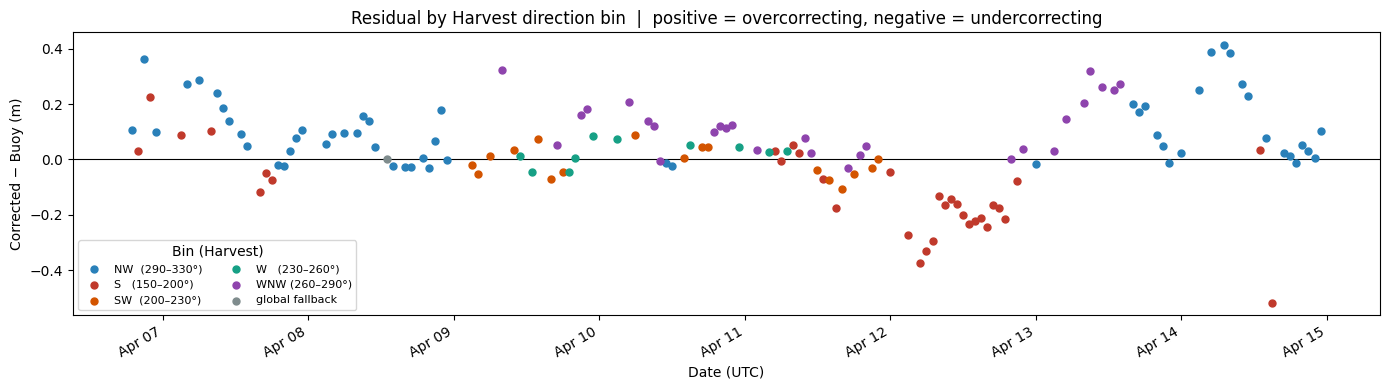

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))

for b, grp in df.groupby('bin'):
    color = BIN_COLOR.get(b, '#7f8c8d')
    ax.scatter(grp['time'], grp['bias_corr'],
               color=color, label=b, s=25, zorder=3)

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Corrected − Buoy (m)')
ax.set_xlabel('Date (UTC)')
ax.set_title('Residual by Harvest direction bin  |  positive = overcorrecting, negative = undercorrecting')
ax.legend(title='Bin (Harvest)', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 3 · Overall bias

Aggregate skill metrics comparing MOP raw vs corrected against buoy ground truth. 

Note: overall stats will look cleaner than per-bin reality — the NW overcorrection and S undercorrection are partially canceling each other out in the mean.

In [20]:
def rmse(x): return np.sqrt(np.mean(x**2))
def mae(x):  return np.mean(np.abs(x))

summary = pd.DataFrame({
    'mean bias': [df['bias_raw'].mean(),  df['bias_corr'].mean()],
    'RMSE':      [rmse(df['bias_raw']),   rmse(df['bias_corr'])],
    'MAE':       [mae(df['bias_raw']),    mae(df['bias_corr'])],
    'R²':        [
        np.corrcoef(df['mop_raw'],   df['buoy_Hs'])[0,1]**2,
        np.corrcoef(df['corrected'], df['buoy_Hs'])[0,1]**2,
    ]
}, index=['MOP raw', 'MOP corrected']).round(3)

summary

,mean bias,RMSE,MAE,R²
MOP raw,-0.103,0.152,0.121,0.638
MOP corrected,0.035,0.154,0.113,0.582


### 3.1 Scatter — corrected vs buoy

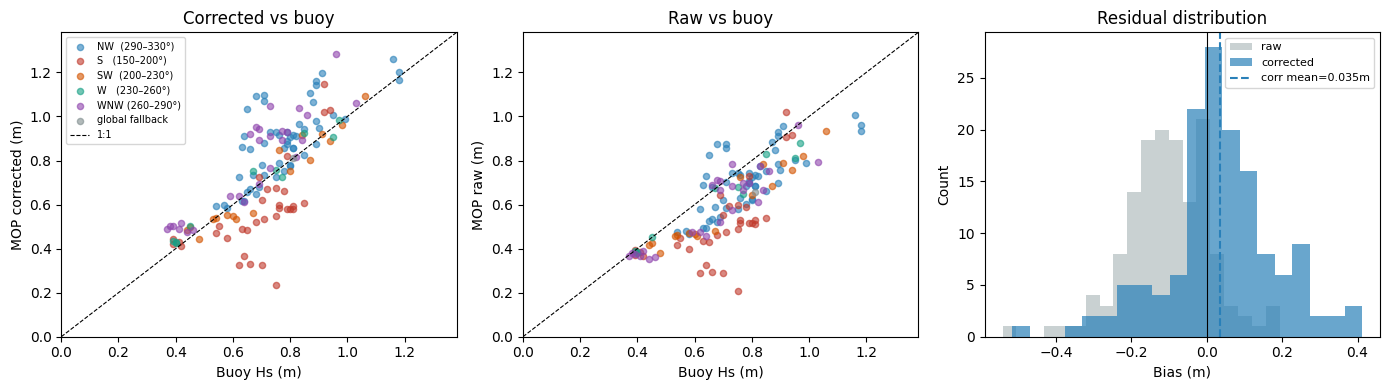

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# panel 1: corrected vs buoy
ax = axes[0]
lim = [0, max(df['corrected'].max(), df['buoy_Hs'].max()) + 0.1]
for b, grp in df.groupby('bin'):
    ax.scatter(grp['buoy_Hs'], grp['corrected'],
               color=BIN_COLOR.get(b, '#7f8c8d'), s=20, alpha=0.6, label=b)
ax.plot(lim, lim, 'k--', lw=0.8, label='1:1')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Buoy Hs (m)'); ax.set_ylabel('MOP corrected (m)')
ax.set_title('Corrected vs buoy')
ax.legend(fontsize=7)

# panel 2: raw vs buoy for comparison
ax = axes[1]
for b, grp in df.groupby('bin'):
    ax.scatter(grp['buoy_Hs'], grp['mop_raw'],
               color=BIN_COLOR.get(b, '#7f8c8d'), s=20, alpha=0.6)
ax.plot(lim, lim, 'k--', lw=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Buoy Hs (m)'); ax.set_ylabel('MOP raw (m)')
ax.set_title('Raw vs buoy')

# panel 3: residual histogram
ax = axes[2]
ax.hist(df['bias_raw'],  bins=20, alpha=0.5, color='#95a5a6', label='raw')
ax.hist(df['bias_corr'], bins=20, alpha=0.7, color='#2980b9', label='corrected')
ax.axvline(0, color='black', lw=0.8)
ax.axvline(df['bias_corr'].mean(), color='#2980b9', lw=1.5, ls='--',
           label=f"corr mean={df['bias_corr'].mean():.3f}m")
ax.set_xlabel('Bias (m)'); ax.set_ylabel('Count')
ax.set_title('Residual distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.2 Residual vs Hs magnitude

Checking whether bias is flat across wave heights or grows with swell size. A slope here would mean the correction needs to be nonlinear.

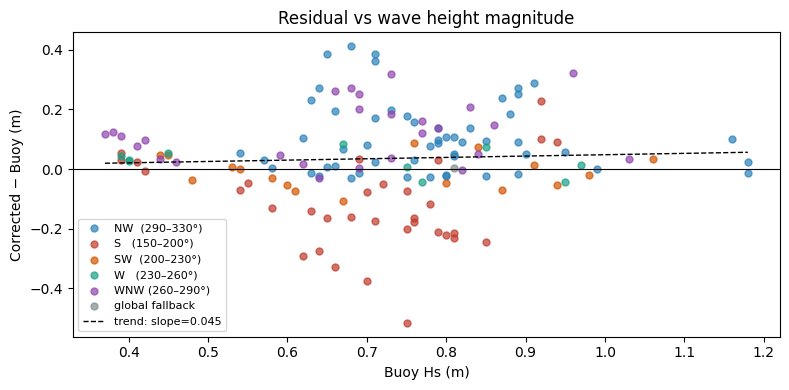

Regression slope: 0.045  intercept: 0.003
A non-zero slope suggests the scale factor should vary with Hs magnitude


In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

for b, grp in df.groupby('bin'):
    ax.scatter(grp['buoy_Hs'], grp['bias_corr'],
               color=BIN_COLOR.get(b, '#7f8c8d'), s=25, alpha=0.7, label=b)

# fit a simple regression line to see if there's a slope
m, c = np.polyfit(df['buoy_Hs'], df['bias_corr'], 1)
x = np.linspace(df['buoy_Hs'].min(), df['buoy_Hs'].max(), 100)
ax.plot(x, m*x + c, 'k--', lw=1, label=f'trend: slope={m:.3f}')

ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Buoy Hs (m)')
ax.set_ylabel('Corrected − Buoy (m)')
ax.set_title('Residual vs wave height magnitude')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Regression slope: {m:.3f}  intercept: {c:.3f}")
print("A non-zero slope suggests the scale factor should vary with Hs magnitude")

## 4 · Direction bin analysis

How well does each direction bin's scale factor perform against the buoy? Bins are assigned from Harvest offshore direction.

In [23]:
bin_stats = df.groupby('bin').apply(lambda g: pd.Series({
    'n':         len(g),
    'mean_bias': g['bias_corr'].mean(),
    'rmse':      rmse(g['bias_corr']),
    'mae':       mae(g['bias_corr']),
    'mean_buoy_Hs': g['buoy_Hs'].mean(),
    'mean_corrected': g['corrected'].mean(),
    'scale_factor': g['scale'].iloc[0],
})).round(3)

bin_stats

,n,mean_bias,rmse,mae,mean_buoy_Hs,mean_corrected,scale_factor
bin,,,,,,,
NW (290–330°),54.0,0.106,0.159,0.114,0.781,0.887,1.252
S (150–200°),33.0,-0.123,0.195,0.159,0.693,0.569,1.126
SW (200–230°),17.0,-0.011,0.055,0.047,0.709,0.699,1.170
W (230–260°),10.0,0.024,0.048,0.042,0.660,0.684,1.116
WNW (260–290°),27.0,0.123,0.158,0.126,0.666,0.790,1.336
global fallback,1.0,0.003,0.003,0.003,0.810,0.813,1.233


### 4.1 Mean bias by bin

Positive = overcorrecting, negative = undercorrecting.
Bar height shows the magnitude of error for each Harvest direction bin.

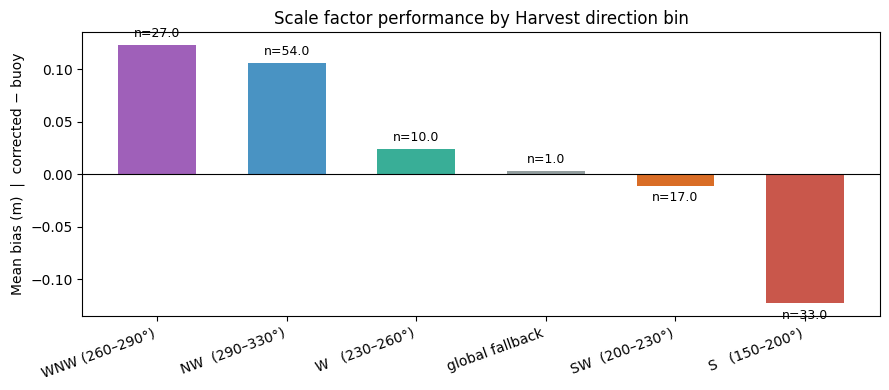

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))

bins_ordered = bin_stats.sort_values('mean_bias', ascending=False).index
colors = [BIN_COLOR.get(b, '#7f8c8d') for b in bins_ordered]
biases = bin_stats.loc[bins_ordered, 'mean_bias']
ns     = bin_stats.loc[bins_ordered, 'n']

bars = ax.bar(range(len(bins_ordered)), biases, color=colors, alpha=0.85, width=0.6)
ax.axhline(0, color='black', lw=0.8)

# annotate n on each bar
for i, (bias, n) in enumerate(zip(biases, ns)):
    va = 'bottom' if bias >= 0 else 'top'
    offset = 0.005 if bias >= 0 else -0.005
    ax.text(i, bias + offset, f'n={n}', ha='center', va=va, fontsize=9)

ax.set_xticks(range(len(bins_ordered)))
ax.set_xticklabels([b.strip() for b in bins_ordered], rotation=20, ha='right')
ax.set_ylabel('Mean bias (m)  |  corrected − buoy')
ax.set_title('Scale factor performance by Harvest direction bin')

plt.tight_layout()
plt.show()

### 4.2 RMSE by bin

RMSE captures both bias and scatter. A bin can have low mean bias but high RMSE if individual predictions are noisy around the truth.

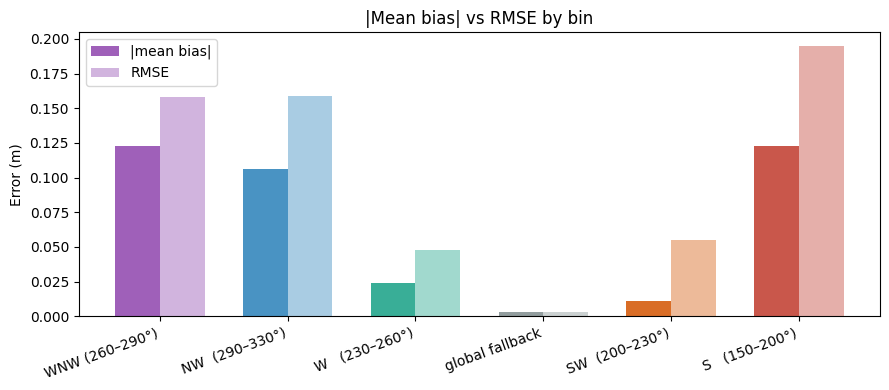

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(bins_ordered))
width = 0.35

ax.bar(x - width/2, np.abs(biases),
       width=width, color=colors, alpha=0.85, label='|mean bias|')
ax.bar(x + width/2, bin_stats.loc[bins_ordered, 'rmse'],
       width=width, color=colors, alpha=0.4, label='RMSE')

ax.set_xticks(x)
ax.set_xticklabels([b.strip() for b in bins_ordered], rotation=20, ha='right')
ax.set_ylabel('Error (m)')
ax.set_title('|Mean bias| vs RMSE by bin')
ax.legend()

plt.tight_layout()
plt.show()

### 4.3 Scatter subplots by bin

One panel per bin: corrected vs buoy Hs with 1:1 reference line. Points colored by confidence level within each bin.

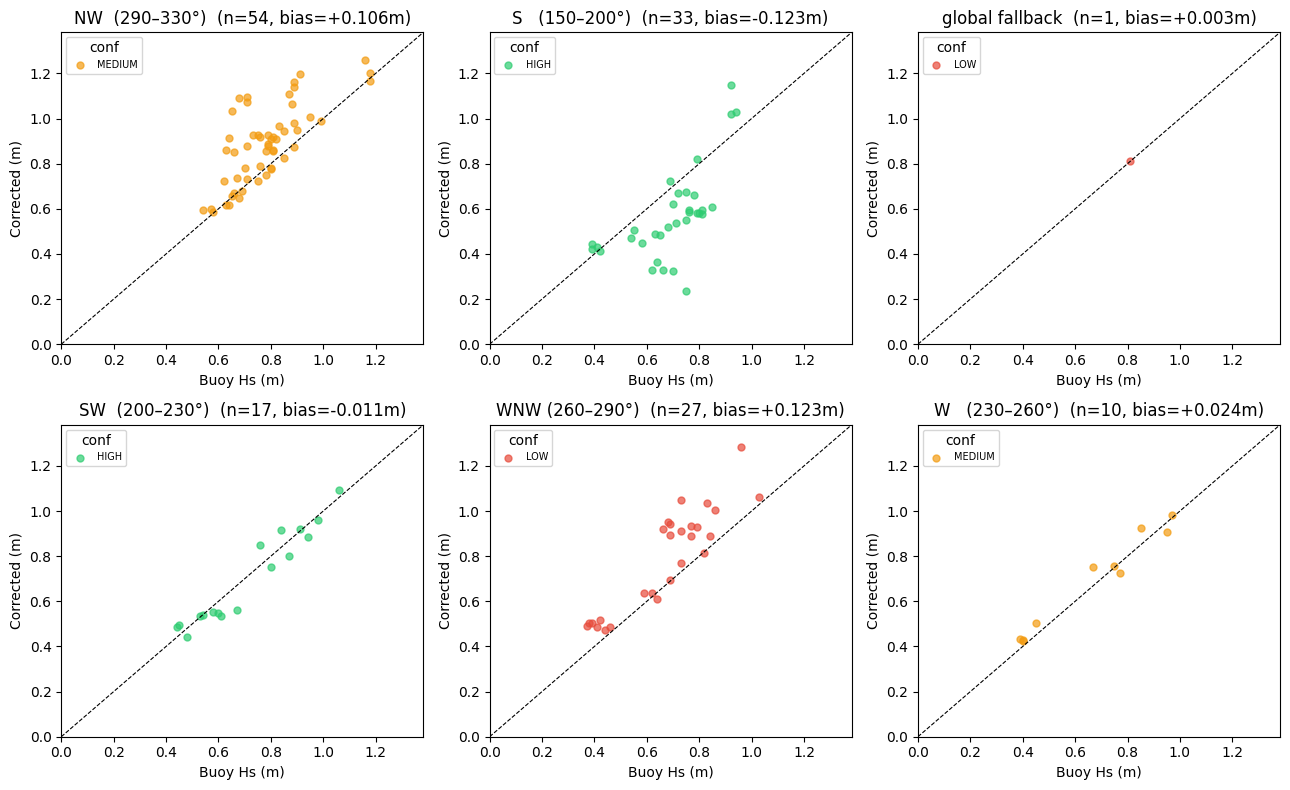

In [26]:
bins_list = [b for b in df['bin'].unique()]
ncols = 3
nrows = int(np.ceil(len(bins_list) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = axes.flatten()

lim = [0, max(df['corrected'].max(), df['buoy_Hs'].max()) + 0.1]

for i, b in enumerate(bins_list):
    ax = axes[i]
    grp = df[df['bin'] == b]
    
    for conf, cgrp in grp.groupby('confidence'):
        ax.scatter(cgrp['buoy_Hs'], cgrp['corrected'],
                   color=CONF_COLOR[conf], s=25, alpha=0.7, label=conf)
    
    ax.plot(lim, lim, 'k--', lw=0.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{b.strip()}  (n={len(grp)}, bias={grp['bias_corr'].mean():+.3f}m)")
    ax.set_xlabel('Buoy Hs (m)')
    ax.set_ylabel('Corrected (m)')
    ax.legend(fontsize=7, title='conf')

# hide any unused panels
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5 · Scale factor diagnostics

Current scale factors were fit from an earlier calibration dataset. Here we compute the empirically optimal scale factor for each bin from the buoy validation data and compare against what's currently deployed.

Note: NW and WNW are systematically overcorrecting, S is undercorrecting, SW and W are well-calibrated. WNW carries LOW confidence throughout — treat its optimal factor with appropriate skepticism given n=27.

In [27]:
# empirical optimal: what factor would have made mop_raw match buoy_Hs exactly?
# optimal_scale = buoy_Hs / mop_raw  (already stored as ratio_raw)

sf_analysis = df.groupby('bin').apply(lambda g: pd.Series({
    'n':               len(g),
    'confidence':      g['confidence'].iloc[0],
    'current_scale':   g['scale'].iloc[0],
    'optimal_scale':   g['ratio_raw'].mean(),
    'optimal_std':     g['ratio_raw'].std(),
    'delta':           g['ratio_raw'].mean() - g['scale'].iloc[0],
})).round(4)

sf_analysis

,n,confidence,current_scale,optimal_scale,optimal_std,delta
bin,,,,,,
NW (290–330°),54,MEDIUM,1.2515,1.1175,0.1447,-0.1340
S (150–200°),33,HIGH,1.1260,1.4826,0.5241,0.3566
SW (200–230°),17,HIGH,1.1699,1.1951,0.1010,0.0252
W (230–260°),10,MEDIUM,1.1163,1.0669,0.0707,-0.0494
WNW (260–290°),27,LOW,1.3356,1.1382,0.1378,-0.1974
global fallback,1,LOW,1.2333,1.2291,NaN,-0.0042


### 5.1 Current vs optimal scale factor by bin

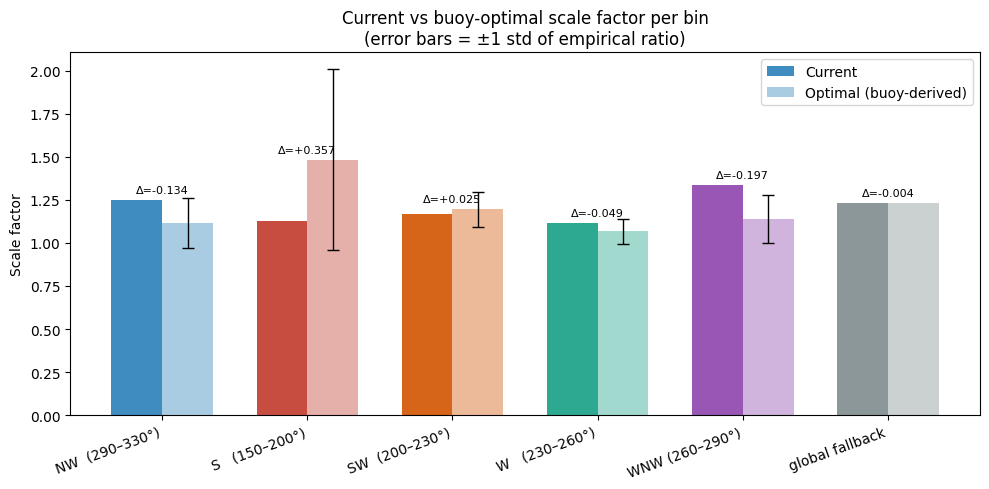

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

bins_list = sf_analysis.index.tolist()
x = np.arange(len(bins_list))
width = 0.35
colors = [BIN_COLOR.get(b, '#7f8c8d') for b in bins_list]

bars_current = ax.bar(x - width/2, sf_analysis['current_scale'],
                      width=width, color=colors, alpha=0.9, label='Current')
bars_optimal = ax.bar(x + width/2, sf_analysis['optimal_scale'],
                      width=width, color=colors, alpha=0.4, label='Optimal (buoy-derived)')

# error bars on optimal showing std across observations
ax.errorbar(x + width/2, sf_analysis['optimal_scale'],
            yerr=sf_analysis['optimal_std'],
            fmt='none', color='black', capsize=4, lw=1)

# annotate delta on each pair
for i, (idx, row) in enumerate(sf_analysis.iterrows()):
    ax.text(i, max(row['current_scale'], row['optimal_scale']) + 0.04,
            f"Δ={row['delta']:+.3f}", ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([b.strip() for b in bins_list], rotation=20, ha='right')
ax.set_ylabel('Scale factor')
ax.set_title('Current vs buoy-optimal scale factor per bin\n(error bars = ±1 std of empirical ratio)')
ax.legend()

plt.tight_layout()
plt.show()

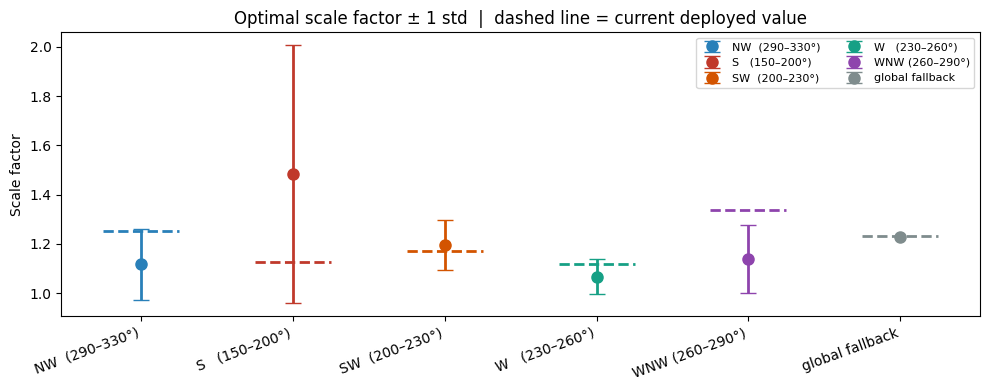

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, (b, row) in enumerate(sf_analysis.iterrows()):
    color = BIN_COLOR.get(b, '#7f8c8d')
    # optimal with std band
    ax.errorbar(i, row['optimal_scale'], yerr=row['optimal_std'],
                fmt='o', color=color, capsize=6, ms=8, lw=2,
                label=b.strip())
    # current as horizontal tick
    ax.plot([i - 0.25, i + 0.25], [row['current_scale'], row['current_scale']],
            color=color, lw=2, ls='--')

ax.set_xticks(range(len(sf_analysis)))
ax.set_xticklabels([b.strip() for b in sf_analysis.index], rotation=20, ha='right')
ax.set_ylabel('Scale factor')
ax.set_title('Optimal scale factor ± 1 std  |  dashed line = current deployed value')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

### 5.3 Recommended updates

Based on buoy validation. Do not update SW or W — they're well-calibrated.
Treat WNW update with caution — LOW confidence bin, n=27.

In [31]:
print("Bin-level scale factor recommendations:\n")
print(f"{'Bin':<22} {'Current':>10} {'Optimal':>10} {'Delta':>8} {'Std':>8} {'n':>5}  {'Action'}")
print("-" * 90)

for b, row in sf_analysis.iterrows():
    if row['n'] < 5:
        action = "insufficient data"
    elif row['optimal_std'] > 0.3:
        action = "HIGH VARIANCE — do not update"
    elif abs(row['delta']) < 0.02:
        action = "keep"
    else:
        action = "UPDATE"
    print(f"{b.strip():<22} {row['current_scale']:>10.4f} {row['optimal_scale']:>10.4f} "
          f"{row['delta']:>+8.4f} {row['optimal_std']:>8.4f} {int(row['n']):>5}  {action}")

Bin-level scale factor recommendations:

Bin                       Current    Optimal    Delta      Std     n  Action
------------------------------------------------------------------------------------------
NW  (290–330°)             1.2515     1.1175  -0.1340   0.1447    54  UPDATE
S   (150–200°)             1.1260     1.4826  +0.3566   0.5241    33  HIGH VARIANCE — do not update
SW  (200–230°)             1.1699     1.1951  +0.0252   0.1010    17  UPDATE
W   (230–260°)             1.1163     1.0669  -0.0494   0.0707    10  UPDATE
WNW (260–290°)             1.3356     1.1382  -0.1974   0.1378    27  UPDATE
global fallback            1.2333     1.2291  -0.0042      nan     1  insufficient data


## 6 · Residual structure

Checking for second-order signals in the residuals beyond what the direction bins explain. Three questions:
1. Is there magnitude-dependent bias within individual bins?
2. Does error grow when offshore swell (Harvest Hs) is larger?
3. Is there a diurnal pattern — time-of-day effects from sea breeze or thermal influence?

If these look like flat noise clouds the current model structure is sufficient.
If any show a trend, that's a second-order correction worth pursuing.

### 6.1 Residual vs buoy Hs — per bin

The aggregate slope in section 3 was ~0.045 (flat). Here we check
whether individual bins have their own magnitude dependence.

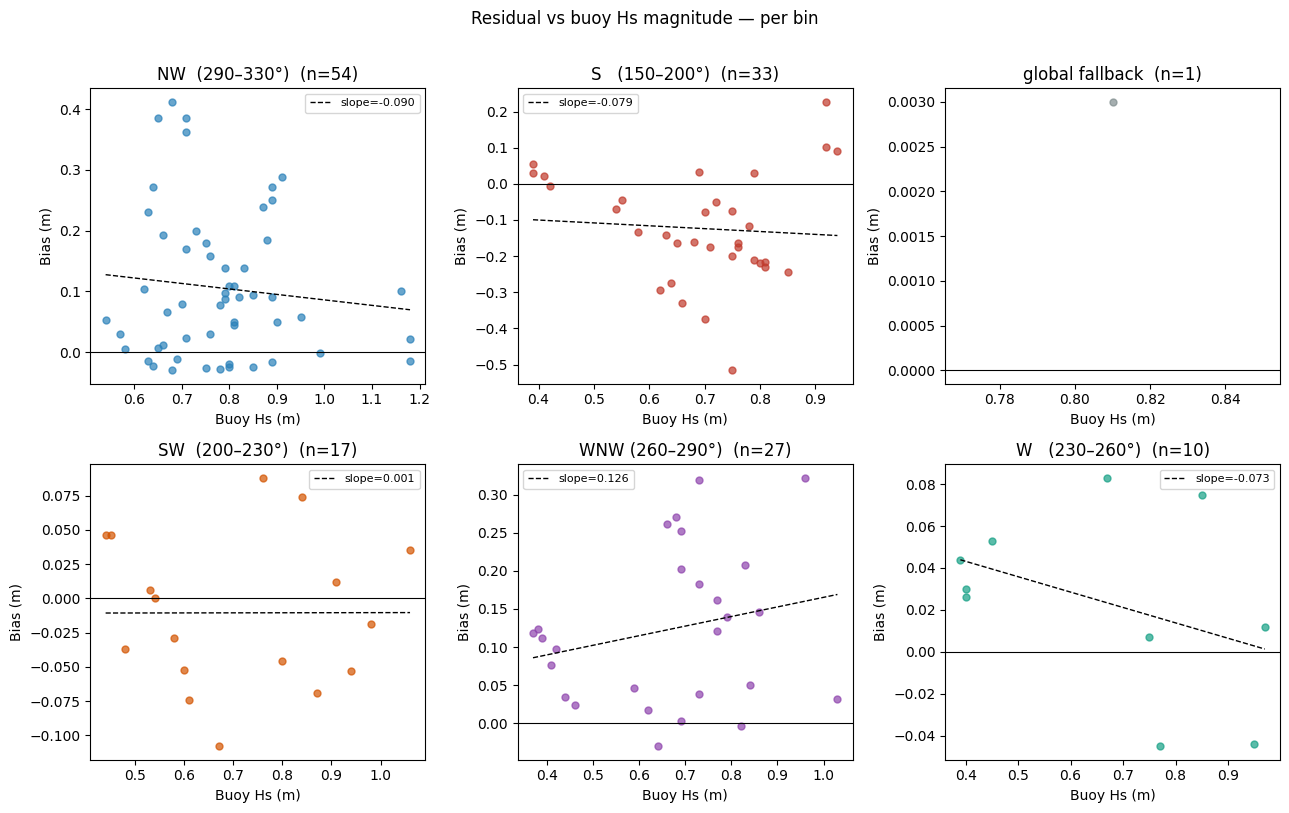

In [32]:
bins_list = [b for b in df['bin'].unique()]
ncols = 3
nrows = int(np.ceil(len(bins_list) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = axes.flatten()

for i, b in enumerate(bins_list):
    ax = axes[i]
    grp = df[df['bin'] == b].copy()
    color = BIN_COLOR.get(b, '#7f8c8d')

    ax.scatter(grp['buoy_Hs'], grp['bias_corr'],
               color=color, s=25, alpha=0.7)
    ax.axhline(0, color='black', lw=0.8)

    # only fit trend if enough points
    if len(grp) >= 5:
        m, c = np.polyfit(grp['buoy_Hs'], grp['bias_corr'], 1)
        x = np.linspace(grp['buoy_Hs'].min(), grp['buoy_Hs'].max(), 100)
        ax.plot(x, m*x + c, 'k--', lw=1, label=f'slope={m:.3f}')
        ax.legend(fontsize=8)

    ax.set_title(f"{b.strip()}  (n={len(grp)})")
    ax.set_xlabel('Buoy Hs (m)')
    ax.set_ylabel('Bias (m)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Residual vs buoy Hs magnitude — per bin', y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Residual vs Harvest Hs

Does error scale with offshore swell energy? If the correction breaks down at higher Harvest values, the scale factor may need an energy-dependent component.

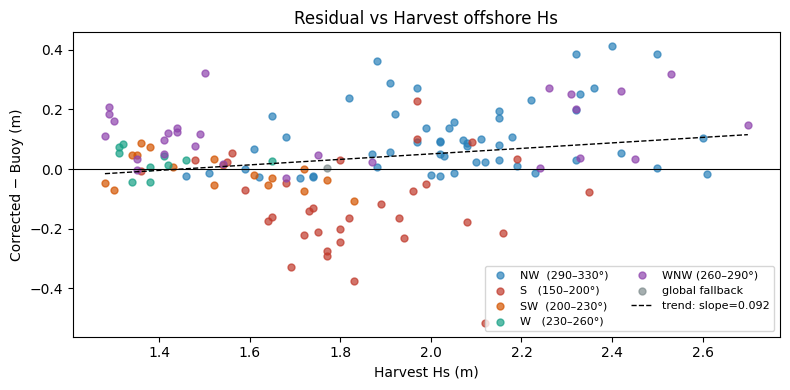

Regression slope: 0.092  intercept: -0.133


In [33]:
fig, ax = plt.subplots(figsize=(8, 4))

for b, grp in df.groupby('bin'):
    ax.scatter(grp['harvest'], grp['bias_corr'],
               color=BIN_COLOR.get(b, '#7f8c8d'), s=25, alpha=0.7, label=b.strip())

m, c = np.polyfit(df['harvest'], df['bias_corr'], 1)
x = np.linspace(df['harvest'].min(), df['harvest'].max(), 100)
ax.plot(x, m*x + c, 'k--', lw=1, label=f'trend: slope={m:.3f}')

ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Harvest Hs (m)')
ax.set_ylabel('Corrected − Buoy (m)')
ax.set_title('Residual vs Harvest offshore Hs')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print(f"Regression slope: {m:.3f}  intercept: {c:.3f}")

### 6.3 Diurnal pattern

Sea breeze at Campus Point typically builds through the afternoon (local time). Checking whether residuals show a systematic time-of-day pattern.
Note: forecast timestamps are UTC, Campus Point is UTC-7.

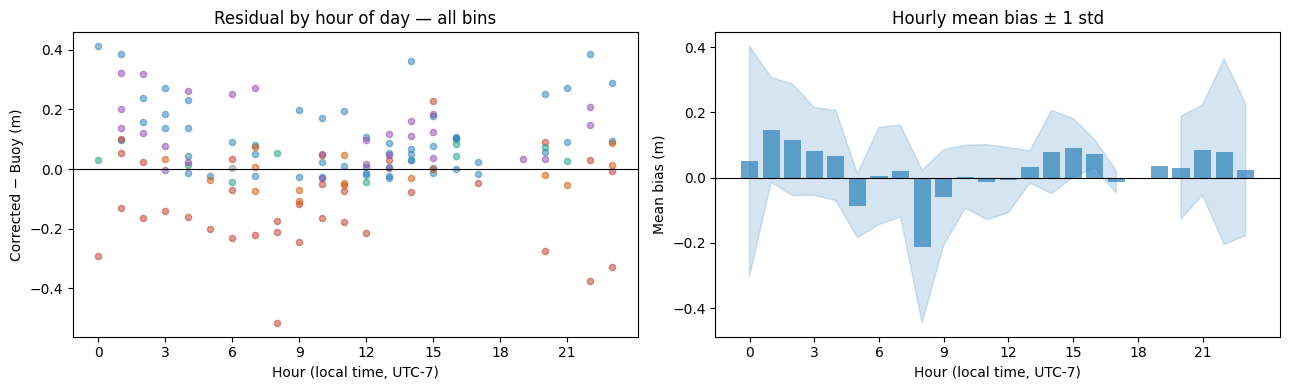

In [34]:
df['hour_local'] = (df['time'].dt.hour - 7) % 24

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# panel 1: scatter of all residuals by local hour
ax = axes[0]
for b, grp in df.groupby('bin'):
    ax.scatter(grp['hour_local'], grp['bias_corr'],
               color=BIN_COLOR.get(b, '#7f8c8d'), s=20, alpha=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Hour (local time, UTC-7)')
ax.set_ylabel('Corrected − Buoy (m)')
ax.set_title('Residual by hour of day — all bins')
ax.set_xticks(range(0, 24, 3))

# panel 2: hourly mean bias with std band
hourly = df.groupby('hour_local')['bias_corr'].agg(['mean', 'std', 'count'])
ax2 = axes[1]
ax2.bar(hourly.index, hourly['mean'],
        color='#2980b9', alpha=0.7, width=0.8)
ax2.fill_between(hourly.index,
                 hourly['mean'] - hourly['std'],
                 hourly['mean'] + hourly['std'],
                 alpha=0.2, color='#2980b9')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xlabel('Hour (local time, UTC-7)')
ax2.set_ylabel('Mean bias (m)')
ax2.set_title('Hourly mean bias ± 1 std')
ax2.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

In [35]:
# Harvest slope
m_harv, _ = np.polyfit(df['harvest'], df['bias_corr'], 1)

# diurnal range
hourly_means = df.groupby('hour_local')['bias_corr'].mean()
diurnal_range = hourly_means.max() - hourly_means.min()

# unexplained variance after removing bin means
df['bin_mean_bias'] = df['bin'].map(df.groupby('bin')['bias_corr'].mean())
df['residual_debiased'] = df['bias_corr'] - df['bin_mean_bias']

print("Residual structure summary:")
print(f"  Harvest Hs slope:        {m_harv:+.3f} m per m  ({'weak' if abs(m_harv) < 0.05 else 'meaningful'})")
print(f"  Diurnal range:           {diurnal_range:.3f} m  ({'weak' if diurnal_range < 0.1 else 'meaningful'})")
print(f"  RMSE after bin debiasing: {rmse(df['residual_debiased']):.3f} m")
print(f"  RMSE before debiasing:    {rmse(df['bias_corr']):.3f} m")
print(f"  Variance explained by bins: {(1 - (df['residual_debiased'].var() / df['bias_corr'].var()))*100:.1f}%")

Residual structure summary:
  Harvest Hs slope:        +0.092 m per m  (meaningful)
  Diurnal range:           0.358 m  (meaningful)
  RMSE after bin debiasing: 0.114 m
  RMSE before debiasing:    0.154 m
  Variance explained by bins: 42.2%


## 7 · Summary & conclusions

### What this notebook validated

142 matched forecast-buoy pairs across April 6–15 2026, covering six
Harvest direction bins. Overall the correction pipeline is working —
mean bias after correction is +0.035m against a raw bias of −0.123m.
But aggregate performance masks meaningful bin-level structure.

### Scale factor findings

| Bin | Current | Optimal | Action |
|-----|---------|---------|--------|
| NW (290–330°) | 1.2515 | 1.1175 | UPDATE — clear systematic overcorrection, n=54, std=0.14 |
| WNW (260–290°) | 1.3356 | 1.1382 | UPDATE — but conservative, LOW confidence bin throughout |
| SW (200–230°) | 1.1699 | 1.1951 | marginal, keep and revisit with more data |
| W (230–260°) | 1.1163 | 1.0669 | UPDATE — clean signal, tight std, note small n=10 |
| S (150–200°) | 1.1260 | 1.4826 | DO NOT UPDATE — std=0.52, high variance, needs investigation |
| global fallback | 1.2333 | — | n=1, ignore |

### S bin requires separate investigation

The S bin has the largest sample size (n=33) and highest confidence
label, yet the worst and most inconsistent performance. The optimal
scale factor estimate has std=0.52 — nearly as large as the factor
itself. Possible causes:

- Direction spread within the 150–200° bin is large — swells arriving
  at 155° vs 195° interact very differently with the Channel Islands
- Period-dependent shadowing: longer-period S swell refracts differently
  around the islands than short-period wind swell from the same direction
- The late-period deterioration (Apr 12–15) suggests a specific swell
  event rather than a stable calibration problem

### What the bins don't explain

Direction bins account for 42.2% of total forecast variance. The
remaining 57.8% is irreducible with the current model structure.
Likely sources:

- Within-bin swell period and direction spread variability
- MOP model noise independent of direction
- Offshore energy dependence (Harvest slope = +0.092 m/m)

The apparent diurnal signal (range 0.358m) is not interpreted as
a real sea breeze effect — with 9 days of data, hourly bin composition
confounds any genuine time-of-day pattern.

### Next steps

1. Update NW and WNW scale factors in forecast.py
2. Update W scale factor, note small n
3. Hold S — collect more observations across diverse S swell events
   before touching its scale factor
4. As the forecast log grows, rerun this notebook monthly to track
   whether optimal factors are stable across seasons
5. Consider splitting S bin into S-short (Tp < 10s) and S-long (Tp > 10s)
   as a hypothesis for why within-bin variance is so high

In [36]:
import requests
import pandas as pd
import io
import sys
from datetime import datetime, timezone, timedelta

TOKEN = "1bc9848d3e524c34a1eb220e121d9a9e"
end   = datetime.now(timezone.utc)
start = end - timedelta(hours=2)

resp = requests.get(
    "https://api.sofarocean.com/fetch/download",
    params={
        "spotterId":         "SPOT-1644",
        "startDate":         start.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
        "endDate":           end.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
        "processingSources": "all",
    },
    headers={
        "View_token": TOKEN,
        "Origin":     "https://spotter.sofarocean.com",
        "Referer":    "https://spotter.sofarocean.com/",
    },
    timeout=15,
)

print(resp.status_code)
print(resp.text[:500])

200
Battery Voltage (V),Power (W),Humidity (%rel),Epoch Time,Significant Wave Height (m),Peak Period (s),Mean Period (s),Peak Direction (deg),Peak Directional Spread (deg),Mean Direction (deg),Mean Directional Spread (deg),Latitude (deg),Longitude (deg),f,df,a1,b1,a2,b2,varianceDensity,direction,directionalSpread,Wind Speed (m/s),Wind Direction (deg),Surface Temperature (°C),Partition0 Start Frequency (hz),Partition0 End Frequency (hz),Partition0 Significant Wave Height (m),Partition0 Mean Period (s
